In [1]:
##importing necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from google.colab import drive

##mounting the drive
drive.mount('/content/drive')

##loading the dataset from the drive
file_path = '/content/drive/My Drive/churn_prediction.csv'
data = pd.read_csv(file_path)


Mounted at /content/drive


In [ ]:
data.head(7), data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  object 
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  object 
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   days_since_last_transaction     25159 non-null  float64
 10  current_balance                 28382 non-null  float64
 11  previous_month_end_balance      28382 non-null  float64
 12  average_monthly_balance_prevQ   

(   customer_id  vintage  age  gender  dependents     occupation    city  \
 0            1     3135   66    Male         0.0  self_employed   187.0   
 1            2      310   35    Male         0.0  self_employed     NaN   
 2            4     2356   31    Male         0.0       salaried   146.0   
 3            5      478   90     NaN         NaN  self_employed  1020.0   
 4            6     2531   42    Male         2.0  self_employed  1494.0   
 5            7      263   42  Female         0.0  self_employed  1096.0   
 6            8     5922   72    Male         0.0        retired  1020.0   
 
    customer_nw_category  branch_code  days_since_last_transaction  ...  \
 0                     2          755                        224.0  ...   
 1                     2         3214                         60.0  ...   
 2                     2           41                          NaN  ...   
 3                     2          582                        147.0  ...   
 4             

In [2]:
#checking for null values
data.isnull().sum()

,0
customer_id,0
vintage,0
age,0
gender,525
dependents,2463
occupation,80
city,803
customer_nw_category,0
branch_code,0
days_since_last_transaction,3223


In [ ]:
duplicates = data.duplicated().sum()

# Print the number of duplicate rows
print(f"\nNumber of Duplicate Rows: {duplicates}")


Number of Duplicate Rows: 0


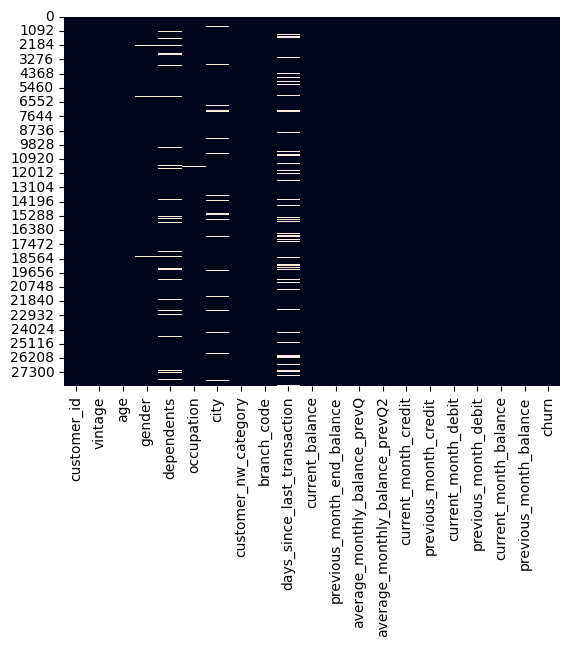

In [ ]:
import seaborn as sns
#understanding the pattern of missing values
sns.heatmap(data.isnull(), cbar=False)
plt.show()

In [ ]:
missing_percentage = data.isnull().mean() * 100
print(missing_percentage)

customer_id                        0.000000
vintage                            0.000000
age                                0.000000
gender                             1.849764
dependents                         8.678035
occupation                         0.281869
city                               2.829258
customer_nw_category               0.000000
branch_code                        0.000000
days_since_last_transaction       11.355789
current_balance                    0.000000
previous_month_end_balance         0.000000
average_monthly_balance_prevQ      0.000000
average_monthly_balance_prevQ2     0.000000
current_month_credit               0.000000
previous_month_credit              0.000000
current_month_debit                0.000000
previous_month_debit               0.000000
current_month_balance              0.000000
previous_month_balance             0.000000
churn                              0.000000
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

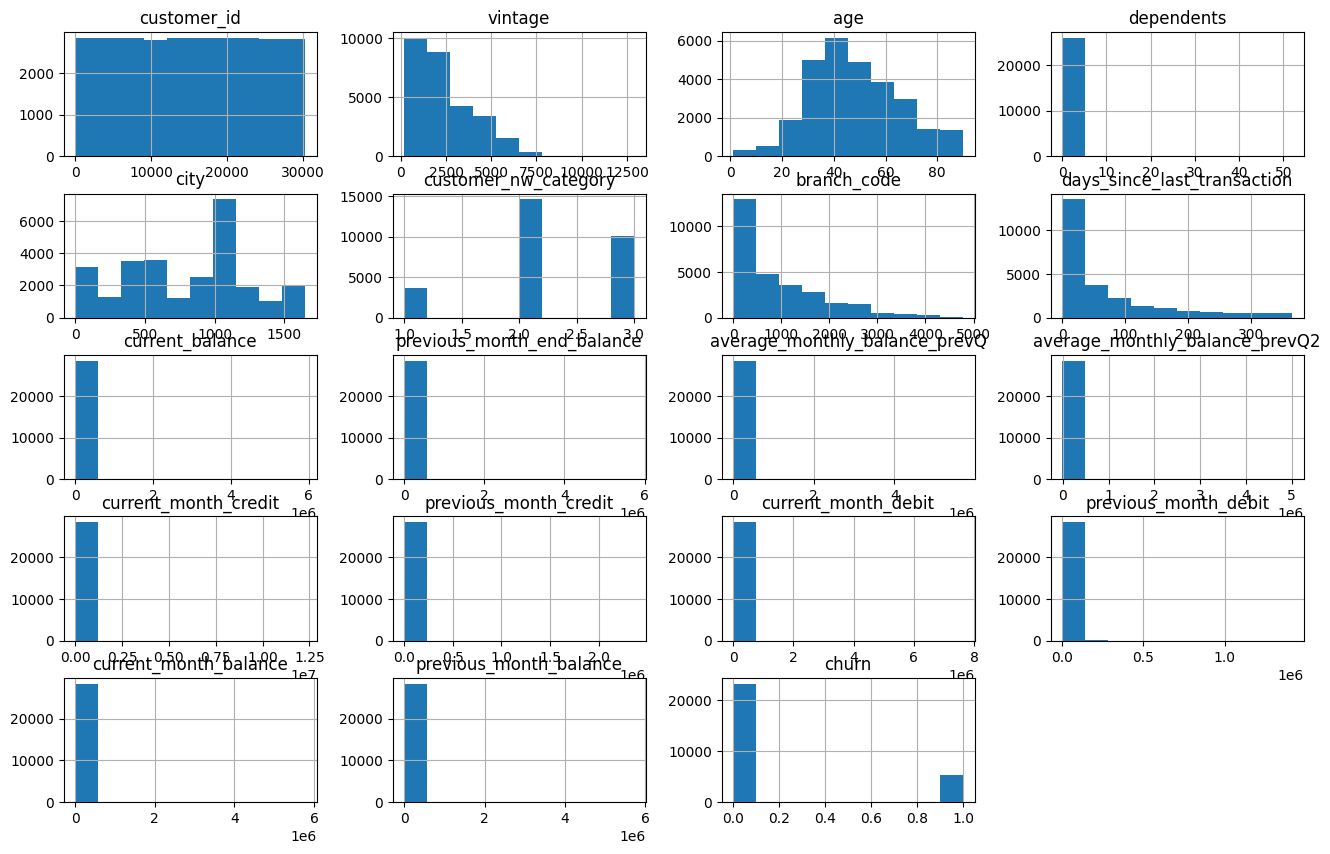

In [ ]:
data.hist(figsize=(16,10))
plt.show

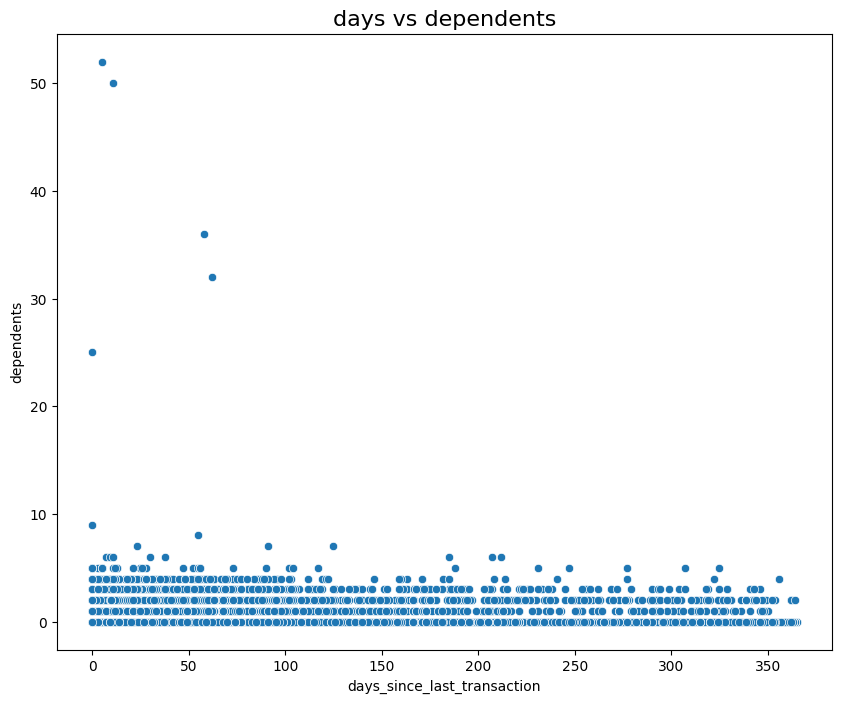

In [ ]:
#visualizing days_since_last_transaction vs dependents
plt.figure(figsize=(10, 8))
sns.scatterplot(data=data, x='days_since_last_transaction', y='dependents')
plt.title('days vs dependents', fontsize=16)
plt.show()


In [3]:
categorical_vars = data.select_dtypes(include=['object']).columns.tolist()
numerical_vars = data.select_dtypes(include=['number']).columns.tolist()

print("Categorical Variables:", categorical_vars)
print("Numerical Variables:", numerical_vars)

Categorical Variables: ['gender', 'occupation']
Numerical Variables: ['customer_id', 'vintage', 'age', 'dependents', 'city', 'customer_nw_category', 'branch_code', 'days_since_last_transaction', 'current_balance', 'previous_month_end_balance', 'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2', 'current_month_credit', 'previous_month_credit', 'current_month_debit', 'previous_month_debit', 'current_month_balance', 'previous_month_balance', 'churn']


In [4]:
for col in categorical_vars:
  data[col].fillna(data[col].mode()[0], inplace=True)

for col in numerical_vars:
  data[col].fillna(data[col].median(), inplace=True)

missing_values_after_imputation = data.isnull().sum()
missing_values_after_imputation[missing_values_after_imputation > 0]

<ipython-input-4-36b7ae637925>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
<ipython-input-4-36b7ae637925>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

,0


In [5]:
data.isnull().sum()

,0
customer_id,0
vintage,0
age,0
gender,0
dependents,0
occupation,0
city,0
customer_nw_category,0
branch_code,0
days_since_last_transaction,0


In [6]:
from sklearn.preprocessing import LabelEncoder

# Initialize a LabelEncoder
label_encoder = LabelEncoder()

# Perform Label Encoding for binary categorical variables (e.g., gender if it's binary)
binary_vars = [col for col in categorical_vars if data[col].nunique() == 2]
for col in binary_vars:
    data[col] = label_encoder.fit_transform(data[col])

# Perform One-Hot Encoding for non-binary categorical variables
multi_category_vars = [col for col in categorical_vars if data[col].nunique() > 2]
data = pd.get_dummies(data, columns=multi_category_vars, drop_first=True)



In [ ]:
data.head()

,customer_id,vintage,age,gender,dependents,city,customer_nw_category,branch_code,days_since_last_transaction,current_balance,...,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,occupation_retired,occupation_salaried,occupation_self_employed,occupation_student
0,1,3135,66,1,0.0,187.0,2,755,224.0,1458.71,...,0.20,0.20,0.20,1458.71,1458.71,0,False,False,True,False
1,2,310,35,1,0.0,834.0,2,3214,60.0,5390.37,...,0.56,5486.27,100.56,6496.78,8787.61,0,False,False,True,False
2,4,2356,31,1,0.0,146.0,2,41,30.0,3913.16,...,0.61,6046.73,259.23,5006.28,5070.14,0,False,True,False,False
3,5,478,90,1,0.0,1020.0,2,582,147.0,2291.91,...,0.47,0.47,2143.33,2291.91,1669.79,1,False,False,True,False
4,6,2531,42,1,2.0,1494.0,3,388,58.0,927.72,...,714.61,588.62,1538.06,1157.15,1677.16,1,False,False,True,False


In [7]:
numerical_vars.remove('churn')

In [8]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical features
data[numerical_vars] = scaler.fit_transform(data[numerical_vars])

# Display the dataset after scaling
print(data.head())

   customer_id   vintage       age  gender  dependents      city  \
0    -1.731304  0.478644  0.999147       1   -0.330877 -1.429857   
1    -1.731190 -1.275909 -0.741756       1   -0.330877  0.086278   
2    -1.730961 -0.005178 -0.966389       1   -0.330877 -1.525933   
3    -1.730847 -1.171568  2.346943       1   -0.330877  0.522137   
4    -1.730733  0.103512 -0.348649       1    1.756001  1.632875   

   customer_nw_category  branch_code  days_since_last_transaction  \
0             -0.341489    -0.182318                     1.927027   
1             -0.341489     2.439824                    -0.066312   
2             -0.341489    -0.943689                    -0.430947   
3             -0.341489    -0.366796                     0.991130   
4              1.172672    -0.573667                    -0.090621   

   current_balance  ...  previous_month_credit  current_month_debit  \
0        -0.139017  ...              -0.109858            -0.070378   
1        -0.046720  ...           

In [9]:
data = data.drop(columns=['customer_id'])



In [10]:
from sklearn.model_selection import train_test_split

# Define the target variable (churn) and separate it from the feature set
X = data.drop(columns=['churn'])  # Feature set (all columns except 'churn')
y = data['churn']  # Target variable (churn)

# Split the dataset into a training set and a testing set (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)



LogisticRegression(random_state=42)

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test set
y_train_pred = log_reg.predict(X_train)  # Predictions on training set
y_pred = log_reg.predict(X_test)

print("Evaluation on Training Set:")
accuracy_train = accuracy_score(y_train, y_train_pred)
print(f"Accuracy: {accuracy_train:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_train, y_train_pred)}")
print(f"Classification Report:\n{classification_report(y_train, y_train_pred)}")

# Evaluate the model on the test set
print("\nEvaluation on Test Set:")
accuracy_test = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")


Evaluation on Training Set:
Accuracy: 0.8244
Confusion Matrix:
[[18381   102]
 [ 3886   336]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     18483
           1       0.77      0.08      0.14      4222

    accuracy                           0.82     22705
   macro avg       0.80      0.54      0.52     22705
weighted avg       0.81      0.82      0.76     22705


Evaluation on Test Set:
Accuracy: 0.8274
Confusion Matrix:
[[4613   26]
 [ 954   84]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      4639
           1       0.76      0.08      0.15      1038

    accuracy                           0.83      5677
   macro avg       0.80      0.54      0.53      5677
weighted avg       0.82      0.83      0.77      5677



The model is seems to be biased to the majority class, thereby imbalance handling. But first we try balancing class weights.

In [ ]:
#giving more priority to class with less distribution to see how the model will perform

log_reg2= LogisticRegression(random_state=42, class_weight='balanced')
log_reg2.fit(X_train, y_train)



LogisticRegression(class_weight='balanced', random_state=42)

In [13]:
# Make predictions on both training and test sets
train_predictions = log_reg.predict(X_train)
test_predictions = log_reg.predict(X_test)

In [14]:
# Training evaluation
print("Training Set Evaluation:")
print(f"Accuracy: {accuracy_score(y_train, train_predictions):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_train, train_predictions))
print("Classification Report:")
print(classification_report(y_train, train_predictions))

# Test evaluation
print("\nTest Set Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, test_predictions):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_predictions))
print("Classification Report:")
print(classification_report(y_test, test_predictions))

Training Set Evaluation:
Accuracy: 0.8244
Confusion Matrix:
[[18381   102]
 [ 3886   336]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     18483
           1       0.77      0.08      0.14      4222

    accuracy                           0.82     22705
   macro avg       0.80      0.54      0.52     22705
weighted avg       0.81      0.82      0.76     22705


Test Set Evaluation:
Accuracy: 0.8274
Confusion Matrix:
[[4613   26]
 [ 954   84]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      4639
           1       0.76      0.08      0.15      1038

    accuracy                           0.83      5677
   macro avg       0.80      0.54      0.53      5677
weighted avg       0.82      0.83      0.77      5677



In [15]:
from imblearn.under_sampling import RandomUnderSampler

# Initialize RandomUnderSampler
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

# Fit and apply the undersampler to the training data
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

# Train the logistic regression model on the undersampled data
log_reg3 = LogisticRegression(random_state=42, class_weight='balanced')
log_reg3.fit(X_train_resampled, y_train_resampled)

# Make predictions on both training and test sets
train_predictions_resampled = log_reg3.predict(X_train_resampled)
test_predictions_resampled = log_reg3.predict(X_test)

# Evaluate the model on the undersampled training set
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Training evaluation
print("Training Set Evaluation (Undersampled):")
print(f"Accuracy: {accuracy_score(y_train_resampled, train_predictions_resampled):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_train_resampled, train_predictions_resampled))
print("Classification Report:")
print(classification_report(y_train_resampled, train_predictions_resampled))

# Test evaluation
print("\nTest Set Evaluation (Undersampled):")
print(f"Accuracy: {accuracy_score(y_test, test_predictions_resampled):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_predictions_resampled))
print("Classification Report:")
print(classification_report(y_test, test_predictions_resampled))


Training Set Evaluation (Undersampled):
Accuracy: 0.7087
Confusion Matrix:
[[3229  993]
 [1467 2755]]
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.76      0.72      4222
           1       0.74      0.65      0.69      4222

    accuracy                           0.71      8444
   macro avg       0.71      0.71      0.71      8444
weighted avg       0.71      0.71      0.71      8444


Test Set Evaluation (Undersampled):
Accuracy: 0.7395
Confusion Matrix:
[[3553 1086]
 [ 393  645]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      4639
           1       0.37      0.62      0.47      1038

    accuracy                           0.74      5677
   macro avg       0.64      0.69      0.65      5677
weighted avg       0.80      0.74      0.76      5677

